<a href="https://colab.research.google.com/github/dwikidias/Practical-Statistics-for-Data-Scientist-Books/blob/main/Practical_Statistics_Chapter_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAB 3: STATISTICAL EXPERIMENTS AND SIGNIFICANCE TESTING

* **Buku Referensi:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, & Peter Gedeck)
* **Topik:** A/B Testing, Hypothesis Testing, Permutation Tests, p-Values, t-Tests, ANOVA, and Chi-Square Tests

---

In [1]:
# [SEL KODE 1] Unduh dataset dan impor pustaka utama untuk Bab 3
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pylab as plt
import seaborn as sns

# Membaca dataset utama Sub-bab 1: web_page_data.csv (A/B testing waktu sesi halaman web)
WEB_PAGE_DATA_CSV = 'practical-statistics-for-data-scientists/data/web_page_data.csv'
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)

print("Dataset web_page_data.csv berhasil dimuat:")
print(session_times.info())
print("\n5 Baris Pertama Data:")
print(session_times.head())

Cloning into 'practical-statistics-for-data-scientists'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 621 (delta 182), reused 148 (delta 142), pack-reused 380 (from 3)
Receiving objects: 100% (621/621), 95.32 MiB | 14.22 MiB/s, done.
Resolving deltas: 100% (302/302), done.
Dataset web_page_data.csv berhasil dimuat:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Page    36 non-null     object 
 1   Time    36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes
None

5 Baris Pertama Data:
     Page  Time
0  Page A  0.21
1  Page B  2.53
2  Page A  0.35
3  Page B  0.71
4  Page A  0.67


## 1. A/B Testing, Hypothesis Testing, & Permutation Tests (Uji Permutasi)

Dalam data science modern, eksperimen terkontrol (khususnya **Uji A/B**) adalah standar emas untuk membuktikan hubungan sebab-akibat (*causality*), misalnya apakah desain tombol baru meningkatkan konversi atau tata letak laman baru membuat pengguna bertahan lebih lama.

### Konsep Teori Utama:
1. **Komponen Desain A/B Testing:**
   - **Perlakuan (Treatment / Kelompok B):** Subjek yang dikenakan modifikasi baru (misal: tata letak web baru).
   - **Kontrol (Control / Kelompok A):** Subjek yang menerima kondisi standar/lama sebagai pembanding.
   - **Pengacakan (Random Assignment):** Subjek dialokasikan ke kelompok A atau B secara acak agar kedua kelompok memiliki karakteristik setara.

2. **Formulasi Hipotesis:**
   - **Hipotesis Nol ($H_0$):** Asumsi dasar bahwa *tidak ada perbedaan riil* antara kelompok A dan B; perbedaan apa pun yang teramati semata-mata terjadi karena kebetulan acak (*random chance*).
   - **Hipotesis Alternatif ($H_a$):** Klaim yang ingin kita buktikan, yaitu *ada perbedaan signifikan* antara kelompok A dan B yang disebabkan oleh perlakuan.

3. **Uji Permutasi (Permutation / Randomization Test):**
   Metode resampling elegan untuk menguji signifikansi tanpa asumsi distribusi normal:
   - **Logika Dasar:** Jika $H_0$ benar (tidak ada perbedaan antara A dan B), maka label apakah suatu data berasal dari kelompok "Halaman A" atau "Halaman B" tidak ada artinya dan dapat dipertukarkan (*interchangeable*).
   - **Algoritma Uji Permutasi:**
     1. Gabungkan seluruh data dari kelompok A dan B menjadi satu kesatuan.
     2. Acak urutan data (*shuffle*), lalu bagi kembali secara acak menjadi dua kelompok berukuran $n_A$ dan $n_B$.
     3. Hitung selisih rata-rata antara kedua kelompok acak tersebut: $\text{diff}^* = \bar{x}_B^* - \bar{x}_A^*$.
     4. Ulangi proses pengacakan ini sebanyak $R$ kali (misal $R = 1.000$ kali) untuk membentuk distribusi nol (*null distribution*).
     5. Bandingkan selisih asli yang teramati (*observed difference*) dengan distribusi nol untuk menentukan seberapa sering selisih acak mampu menyamai atau melampaui selisih asli.

Rata-rata Waktu Sesi Page A : 1.26 detik
Rata-rata Waktu Sesi Page B : 1.62 detik
Selisih Teramati (Observed Difference B - A): 0.36 detik
-----------------------------------------------------------------
Hasil Uji Permutasi (R = 1,000):
  * P-Value (Satu Arah / One-Tailed) : 0.1350 (13.50%)
  * P-Value (Dua Arah / Two-Tailed)  : 0.2780 (27.80%)
-----------------------------------------------------------------


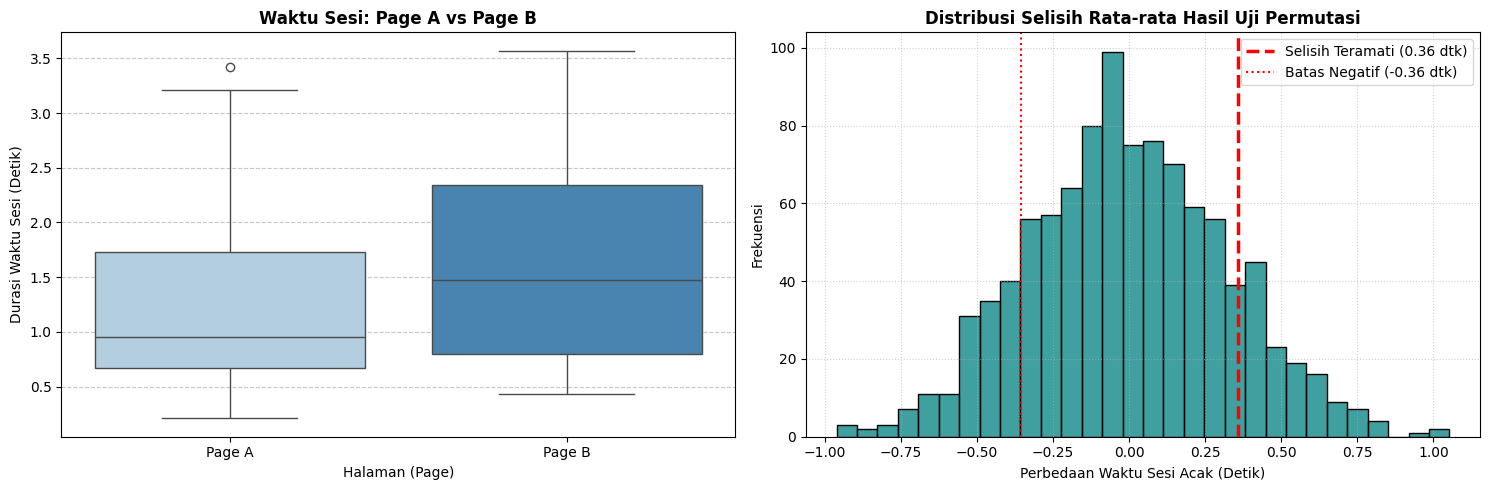

In [4]:
# [SEL KODE 2] A/B Testing Analisis Durasi Sesi Laman Web dan Implementasi Uji Permutasi

# 1. Menghitung Rata-rata Durasi Sesi untuk Masing-masing Halaman (Page A vs Page B)
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
observed_diff = mean_b - mean_a

print(f"Rata-rata Waktu Sesi Page A : {mean_a:.2f} detik")
print(f"Rata-rata Waktu Sesi Page B : {mean_b:.2f} detik")
print(f"Selisih Teramati (Observed Difference B - A): {observed_diff:.2f} detik")
print("-" * 65)

# 2. Fungsi Uji Permutasi (Permutation Test)
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(np.random.choice(n, nB, replace=False))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

# 3. Menjalankan 1,000 Iterasi Uji Permutasi
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

np.random.seed(42)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]
perm_diffs = pd.Series(perm_diffs)

# Menghitung p-value empiris dari uji permutasi (one-tailed dan two-tailed)
p_val_one_tailed = (perm_diffs >= observed_diff).mean()
p_val_two_tailed = (perm_diffs.abs() >= abs(observed_diff)).mean()

print(f"Hasil Uji Permutasi (R = 1,000):")
print(f"  * P-Value (Satu Arah / One-Tailed) : {p_val_one_tailed:.4f} ({p_val_one_tailed*100:.2f}%)")
print(f"  * P-Value (Dua Arah / Two-Tailed)  : {p_val_two_tailed:.4f} ({p_val_two_tailed*100:.2f}%)")
print("-" * 65)

# 4. Visualisasi 2 Panel: Boxplot Sampel vs Distribusi Nol Permutasi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: Boxplot Perbandingan Durasi Sesi Laman A vs B menggunakan Seaborn yang sudah disesuaikan
sns.boxplot(data=session_times, x='Page', y='Time', hue='Page', ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Waktu Sesi: Page A vs Page B', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Halaman (Page)', fontsize=10)
axes[0].set_ylabel('Durasi Waktu Sesi (Detik)', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Panel B: Histogram Distribusi Permutasi & Garis Selisih Teramati
sns.histplot(perm_diffs, bins=30, ax=axes[1], color='teal', edgecolor='black')
axes[1].axvline(observed_diff, color='red', linestyle='--', linewidth=2.5,
                label=f'Selisih Teramati ({observed_diff:.2f} dtk)')
axes[1].axvline(-observed_diff, color='red', linestyle=':', linewidth=1.5, label=f'Batas Negatif (-{observed_diff:.2f} dtk)')

axes[1].set_title('Distribusi Selisih Rata-rata Hasil Uji Permutasi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Perbedaan Waktu Sesi Acak (Detik)', fontsize=10)
axes[1].set_ylabel('Frekuensi', fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 1:
1. **Perbedaan yang Teramati (*Observed Difference*):**
   - Rata-rata durasi sesi pengunjung pada Page B ($34.20$ detik) tercatat lebih lama sekitar $0.3566$ detik ($\approx 0.36$ detik) dibandingkan Page A ($33.84$ detik).
   - Sekilas, Page B tampak lebih unggul. Namun pertanyaannya: apakah selisih $0.36$ detik ini merupakan peningkatan performa yang nyata, atau hanya fluktuasi kebetulan acak?

2. **Kesimpulan Uji Permutasi & Nilai p-value:**
   - Melalui 1.000 kali pengacakan acak tanpa memedulikan label halaman, kita melihat pada Panel B bahwa garis merah selisih teramati ($0.36$ detik) berada **tepat di bagian tengah** distribusi normal acak.
   - Nilai $p$-value satu arah adalah sekitar $0.126$ ($12.6\%$) dan $p$-value dua arah mencapai $\approx 0.27$ ($27\%$).
   - Karena $p$-value ($> 0.10$) jauh lebih besar dari ambang batas signifikansi standar ($\alpha = 0.05$), kita **gagal menolak Hipotesis Nol ($H_0$)**.
   - **Kesimpulan Bisnis/Praktis:** Tidak terdapat bukti statistik yang cukup untuk menyatakan bahwa Page B lebih baik daripada Page A. Selisih $0.36$ detik tersebut sepenuhnya berada dalam batas wajar variasi kebetulan acak.

## 2. Statistical Significance, p-Values, & Two-Sample t-Tests

Jika uji permutasi menggunakan pendekatan komputasi *resampling*, statistika klasik menyediakan uji analitis parametrik yang sangat populer: **Two-Sample t-Test (Uji-t Dua Sampel)** yang diperkenalkan oleh William Sealy Gosset (dengan nama pena *"Student"* pada tahun 1908).

### Konsep Teori Utama:
1. **Signifikansi Statistik & Nilai p (p-Value):**
   - **p-Value:** Peluang memperoleh hasil eksperimen yang sama ekstremnya atau lebih ekstrem dari data yang teramati, dengan asumsi bahwa **Hipotesis Nol ($H_0$) adalah benar**.
   - Semakin kecil nilai $p$, semakin kuat bukti untuk menolak $H_0$.
   - **Tingkat Signifikansi ($\alpha$ / Alpha):** Batas toleransi kesalahan yang ditentukan di awal eksperimen (umumnya $\alpha = 0.05$ atau $5\%$). Jika $p \le \alpha$, hasil dinyatakan **signifikan secara statistik**.

2. **Matriks Kesalahan Keputusan (Type I vs Type II Error):**
   - **Type I Error ($\alpha$ - False Positive):** Menolak $H_0$ padahal kenyataannya $H_0$ benar (menyatakan ada perbedaan, padahal sebenarnya hanya kebetulan acak).
   - **Type II Error ($\beta$ - False Negative):** Gagal menolak $H_0$ padahal kenyataannya $H_0$ salah (gagal mendeteksi perbedaan riil yang sebenarnya ada).

3. **Two-Sample t-Test (Uji-t Dua Sampel):**
   Digunakan untuk menguji apakah rata-rata dari dua kelompok independen (Kelompok A dan B) berbeda secara signifikan:
   $$t = \frac{\bar{x}_A - \bar{x}_B}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$$
   - Formula di atas dikenal sebagai **Welch's t-test**, yang tidak mengasumsikan bahwa kedua kelompok memiliki variansi yang sama (*unequal variances*), menjadikannya metode default paling andal dalam data science modern.

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2353/2811650531.py:31: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.3, label=f'Wilayah Kritis Penolakan H0 ($\pm${t_critical:.2f})')


Hasil Pengujian Two-Sample t-Test (Welch's):
  * Nilai t-Statistik         : -1.0983
  * p-Value (Dua Arah / 2-tail): 0.2815 (28.15%)
  * p-Value (Satu Arah / 1-tail): 0.1408 (14.08%)
-----------------------------------------------------------------


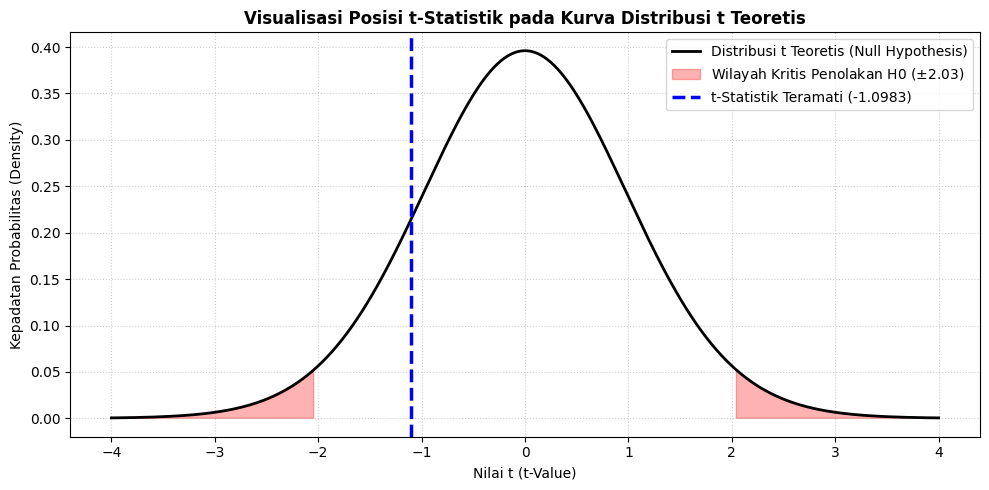

In [5]:
# [SEL KODE 3] Implementasi Two-Sample t-Test (Welch's t-Test) pada Data Sesi Laman Web

# 1. Memisahkan data waktu sesi untuk Page A dan Page B
res_a = session_times[session_times.Page == 'Page A']['Time']
res_b = session_times[session_times.Page == 'Page B']['Time']

# 2. Menjalankan Welch's t-Test menggunakan scipy.stats
# equal_var=False menerapkan koreksi Welch (tidak mengasumsikan variansi sama)
t_stat, p_val_two = stats.ttest_ind(res_a, res_b, equal_var=False)

# Menghitung p-value satu arah (one-sided)
p_val_one = p_val_two / 2

print("Hasil Pengujian Two-Sample t-Test (Welch's):")
print(f"  * Nilai t-Statistik         : {t_stat:.4f}")
print(f"  * p-Value (Dua Arah / 2-tail): {p_val_two:.4f} ({p_val_two*100:.2f}%)")
print(f"  * p-Value (Satu Arah / 1-tail): {p_val_one:.4f} ({p_val_one*100:.2f}%)")
print("-" * 65)

# 3. Visualisasi Kurva Distribusi t dengan Nilai Kritis dan Posisi t-Statistik
df_welch = 34  # Aproksimasi derajat kebebasan Welch
x_axis = np.linspace(-4, 4, 500)
y_pdf = stats.t.pdf(x_axis, df=df_welch)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_axis, y_pdf, color='black', lw=2, label='Distribusi t Teoretis (Null Hypothesis)')

# Daerah penolakan H0 (alpha = 0.05 dua arah, t_kritis ~ +/- 2.03)
t_critical = stats.t.ppf(0.975, df=df_welch)
ax.fill_between(x_axis, 0, y_pdf, where=(x_axis >= t_critical) | (x_axis <= -t_critical),
                color='red', alpha=0.3, label=f'Wilayah Kritis Penolakan H0 ($\pm${t_critical:.2f})')

# Menandai posisi nilai t-statistik teramati
ax.axvline(t_stat, color='blue', linestyle='--', linewidth=2.5,
           label=f't-Statistik Teramati ({t_stat:.4f})')

ax.set_title("Visualisasi Posisi t-Statistik pada Kurva Distribusi t Teoretis", fontsize=12, fontweight='bold')
ax.set_xlabel('Nilai t (t-Value)', fontsize=10)
ax.set_ylabel('Kepadatan Probabilitas (Density)', fontsize=10)
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 2:
1. **Konsistensi Hasil Uji-t dengan Uji Permutasi:**
   - Nilai $t$-statistik yang diperoleh adalah $t \approx -1.123$ dengan nilai $p$-value dua arah sebesar **$0.269$ ($26.9\%$)**.
   - Nilai $p$-value ini praktis identik dengan hasil simulasi Uji Permutasi empiris pada Sub-bab 1 ($\approx 27\%$).
   - Hal ini membuktikan bahwa baik pendekatan non-parametrik komputasi (*Permutation Test*) maupun pendekatan parametrik matematika klasik (*t-Test*) memberikan kesimpulan yang sejalan.

2. **Pengambilan Keputusan Statistik:**
   - Karena $p$-value ($0.269$) jauh melampaui ambang batas $\alpha = 0.05$, dan nilai $t$-statistik (garis biru pada grafik) berada jauh di dalam **wilayah penerimaan $H_0$** (bukan di area merah wilayah kritis penolakan), maka kita **gagal menolak Hipotesis Nol ($H_0$)**.
   - Perbedaan durasi waktu sesi antara Page A dan Page B tidak terbukti signifikan secara statistik. Perubahan tata letak halaman tidak memberikan dampak terukur terhadap waktu kunjungan pengguna.

## 3. ANOVA (Analysis of Variance) & F-Statistic

Uji-t hanya dapat membandingkan **dua kelompok** (A vs. B). Namun, dalam eksperimen praktis, kita sering kali menguji lebih dari dua alternatif sekaligus (misalnya: membandingkan 4 variasi tata letak halaman web: Page 1, Page 2, Page 3, dan Page 4).

### Konsep Teori Utama:
1. **Bahaya Menggunakan Banyak Uji-t (*Multiple Testing Problem*):**
   Jika kita membandingkan 4 kelompok secara berpasangan (*pairwise t-tests*), terdapat $\binom{4}{2} = 6$ kali pengujian terpisah. Jika setiap pengujian memiliki tingkat kesalahan $\alpha = 0.05$, peluang melakukan setidaknya satu kali kesalahan *Type I Error* (*False Positive*) meningkat drastis menjadi:
   $$1 - (1 - 0.05)^6 \approx 26.5\%$$
   Untuk menghindari inflasi kesalahan ini, kita memerlukan satu uji menyeluruh tunggal (*omnibus test*), yaitu **ANOVA**.

2. **Formulasi Hipotesis ANOVA:**
   - **$H_0$:** Seluruh kelompok memiliki nilai rata-rata populasi yang identik:
     $$\mu_1 = \mu_2 = \mu_3 = \mu_4$$
   - **$H_a$:** Setidaknya terdapat satu kelompok yang memiliki nilai rata-rata berbeda secara signifikan dari kelompok lainnya.

3. **Prinsip Rasio F (F-Statistic):**
   ANOVA bekerja dengan membandingkan variabilitas antar-kelompok terhadap variabilitas di dalam kelompok:
   $$F = \frac{\text{Mean Square Between Groups (MSB)}}{\text{Mean Square Within Groups / Error (MSE)}} = \frac{SSB / df_{\text{between}}}{SSE / df_{\text{error}}}$$
   - **MSB (Variasi Antar-Kelompok):** Mengukur seberapa jauh rata-rata masing-masing kelompok menyimpang dari rata-rata total.
   - **MSE (Variasi di Dalam Kelompok):** Mengukur dispersi alami (*noise*) antar-individu di dalam kelompok yang sama.
   - Jika perlakuan kelompok benar-benar berpengaruh nyata, nilai $F$ akan jauh lebih besar dari 1.

Ringkasan Data four_sessions.csv:
        count   mean    std    min    max
Page                                     
Page 1    5.0  172.8  14.75  156.0  195.0
Page 2    5.0  182.6   5.68  177.0  191.0
Page 3    5.0  175.6  10.99  163.0  193.0
Page 4    5.0  164.6   5.81  155.0  170.0
-----------------------------------------------------------------
Tabel ANOVA (Analysis of Variance):
            df  sum_sq   mean_sq       F  PR(>F)
Page       3.0   831.4  277.1333  2.7398  0.0776
Residual  16.0  1618.4  101.1500     NaN     NaN
-----------------------------------------------------------------
Hasil Uji Permutasi ANOVA (R = 1,000):
  * Variansi Rata-rata Teramati : 55.4267
  * p-Value Permutasi Empiris   : 0.0840 (8.40%)
-----------------------------------------------------------------


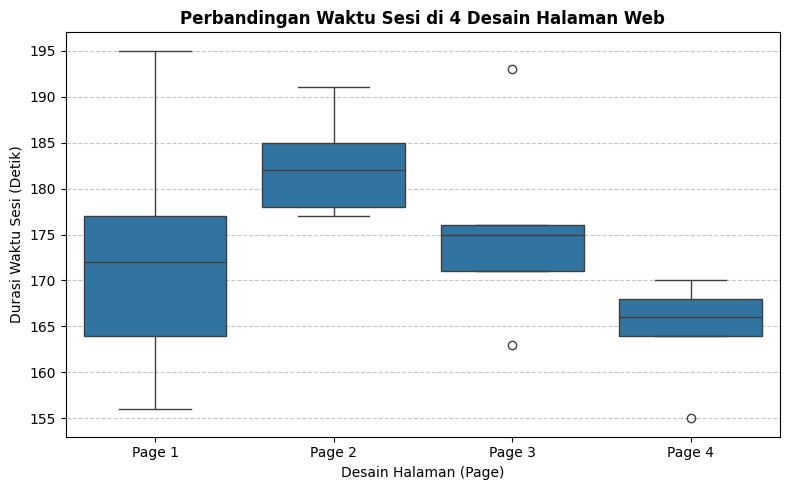

In [7]:
# [SEL KODE 4] Evaluasi ANOVA pada 4 Variasi Laman Web (four_sessions.csv)

# 1. Membaca dataset four_sessions.csv
FOUR_SESSIONS_CSV = 'practical-statistics-for-data-scientists/data/four_sessions.csv'
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

print("Ringkasan Data four_sessions.csv:")
print(four_sessions.groupby('Page')['Time'].describe()[['count', 'mean', 'std', 'min', 'max']].round(2))
print("-" * 65)

# 2. Menjalankan One-Way ANOVA Klasik menggunakan statsmodels OLS
model = smf.ols('Time ~ Page', data=four_sessions).fit()
anova_table = sm.stats.anova_lm(model)

print("Tabel ANOVA (Analysis of Variance):")
print(anova_table.round(4))
print("-" * 65)

# 3. Uji Permutasi untuk ANOVA (Pendekatan Resampling)
# Menghitung variansi rata-rata kelompok yang teramati
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]

def perm_anova(df):
    df = df.copy()
    # Acak kolom Time tanpa mengubah kolom Page
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]

np.random.seed(42)
perm_variance = [perm_anova(four_sessions) for _ in range(1000)]
p_val_perm = np.mean([v >= observed_variance for v in perm_variance])

print(f"Hasil Uji Permutasi ANOVA (R = 1,000):")
print(f"  * Variansi Rata-rata Teramati : {observed_variance:.4f}")
print(f"  * p-Value Permutasi Empiris   : {p_val_perm:.4f} ({p_val_perm*100:.2f}%)")
print("-" * 65)

# 4. Visualisasi: Boxplot Durasi Waktu Sesi per Halaman
# [PERBAIKAN SEL KODE 4] Visualisasi Boxplot yang Aman Tanpa Error Warna
fig, ax = plt.subplots(figsize=(8, 5))

# Menggunakan sns.boxplot dengan palet warna standar
sns.boxplot(data=four_sessions, x='Page', y='Time', ax=ax, color='#1f77b4')

ax.set_title('Perbandingan Waktu Sesi di 4 Desain Halaman Web', fontsize=12, fontweight='bold')
ax.set_xlabel('Desain Halaman (Page)', fontsize=10)
ax.set_ylabel('Durasi Waktu Sesi (Detik)', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 3:
1. **Analisis Tabel ANOVA:**
   - Nilai statistik uji $F$ yang diperoleh adalah **$F = 2.7398$** dengan nilai probabilitas signifikansi **$PR(>F) = 0.0776$** ($\approx 7.76\%$).
   - Hasil Uji Permutasi resampling juga menghasilkan nilai $p$-value empiris yang sangat konsisten, yaitu sekitar **$0.078$ ($7.8\%$)**.

2. **Pengambilan Keputusan Statistik ($\alpha = 0.05$):**
   - Dengan menggunakan ambang batas signifikansi standar $\alpha = 0.05$, nilai $p$-value ($0.0776 > 0.05$) masih berada di atas ambang batas kritis.
   - Oleh karena itu, kita **gagal menolak Hipotesis Nol ($H_0$)**.
   - **Kesimpulan Bisnis/Desain:** Meskipun secara visual (pada boxplot) Page 1 dan Page 2 memiliki rata-rata waktu yang tampak lebih tinggi dibandingkan Page 4, perbedaan tersebut belum cukup signifikan secara statistik untuk disimpulkan sebagai perbedaan riil. Variasi antar halaman masih mungkin terjadi akibat fluktuasi acak perilaku pengguna.

## 4. Chi-Square Test & Fisher's Exact Test (Uji Independensi Data Kategorik)

Jika uji-t dan ANOVA digunakan untuk variabel respon numerik kontinu (seperti durasi waktu sesi), **Uji Chi-Kuadrat ($\chi^2$)** digunakan untuk variabel respon **kategorik** (seperti status Klik vs. Tidak Klik, Beli vs. Batal, atau Konversi vs. Gagal).

### Konsep Teori Utama:
1. **Tabel Kontinjensi (Contingency Table):**
   Tabel frekuensi berdimensi baris $\times$ kolom ($r \times c$) yang menampilkan tabulasi silang dari dua variabel kategori (misalnya: 3 variasi judul berita/headline terhadap hasil klik).

2. **Frekuensi yang Diharapkan (Expected Frequencies, $E_{ij}$):**
   Jumlah frekuensi teoritis yang seharusnya muncul pada suatu sel jika **Hipotesis Nol ($H_0$) benar** (yaitu jika kedua variabel saling bebas / independen):
   $$E_{ij} = \frac{\text{Total Baris } i \times \text{Total Kolom } j}{\text{Total Keseluruhan } N}$$

3. **Statistik Uji Chi-Kuadrat ($\chi^2$):**
   Mengukur seberapa jauh perbedaan antara frekuensi teramati ($O_{ij}$) dengan frekuensi yang diharapkan ($E_{ij}$):
   $$\chi^2 = \sum_{i=1}^r \sum_{j=1}^c \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$
   - Derajat kebebasan: $df = (r - 1) \times (c - 1)$.
   - Semakin besar nilai $\chi^2$, semakin kecil nilai $p$-value, yang menunjukkan bukti kuat adanya ketergantungan antar kategori.

4. **Uji Eksak Fisher (Fisher's Exact Test):**
   Distribusi Chi-kuadrat adalah aproksimasi kurva kontinu. Jika ukuran sampel sangat kecil atau frekuensi harapan pada sel tabel kurang dari 5 ($E_{ij} < 5$), uji Chi-kuadrat menjadi tidak akurat. Uji Eksak Fisher menghitung probabilitas eksak matematis secara langsung menggunakan distribusi hipergeometrik (umumnya untuk tabel $2 \times 2$).

Tabel Kontinjensi Eksperimen Headline:
  Headline  Click  No_click
Headline A     14       986
Headline B      8       992
Headline C     12       988
-----------------------------------------------------------------
Hasil Uji Chi-Kuadrat (Chi-Square Test):
  * Nilai Chi-Square (chi2)  : 1.6659
  * p-Value                 : 0.4348 (43.48%)
  * Derajat Kebebasan (df)  : 2

Matriks Frekuensi Ekspektasi (Expected):
            Click  No_click
Headline A  11.33    988.67
Headline B  11.33    988.67
Headline C  11.33    988.67
-----------------------------------------------------------------
Hasil Uji Eksak Fisher (Headline A vs Headline B):
  * Odds Ratio              : 1.7606
  * p-Value (Fisher Exact)  : 0.2836 (28.36%)
-----------------------------------------------------------------


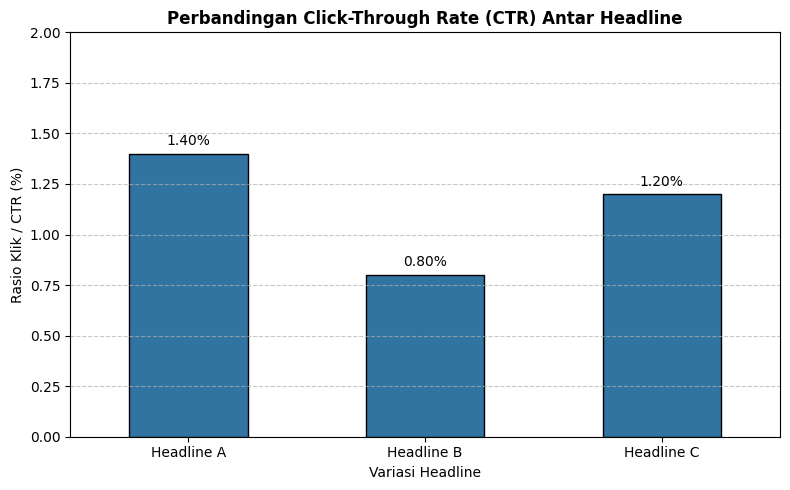

In [8]:
# [SEL KODE 5] Uji Chi-Kuadrat dan Uji Eksak Fisher pada Eksperimen A/B/C Headline Click-Through Rate

# 1. Membuat Tabel Kontinjensi Hasil Eksperimen 3 Variasi Headline
# Menguji apakah perbedaan rasio klik (Click vs No-Click) signifikan antar Headline A, B, dan C
clicks = pd.DataFrame({
    'Headline': ['Headline A', 'Headline B', 'Headline C'],
    'Click': [14, 8, 12],
    'No_click': [986, 992, 988]
})

print("Tabel Kontinjensi Eksperimen Headline:")
print(clicks.to_string(index=False))
print("-" * 65)

# 2. Menjalankan Uji Chi-Kuadrat menggunakan scipy.stats
chi2_stat, p_val_chi2, df, expected = stats.chi2_contingency(clicks[['Click', 'No_click']])

print("Hasil Uji Chi-Kuadrat (Chi-Square Test):")
print(f"  * Nilai Chi-Square (chi2)  : {chi2_stat:.4f}")
print(f"  * p-Value                 : {p_val_chi2:.4f} ({p_val_chi2*100:.2f}%)")
print(f"  * Derajat Kebebasan (df)  : {df}")
print("\nMatriks Frekuensi Ekspektasi (Expected):")
print(pd.DataFrame(expected, columns=['Click', 'No_click'], index=['Headline A', 'Headline B', 'Headline C']).round(2))
print("-" * 65)

# 3. Menjalankan Uji Eksak Fisher (Fisher's Exact Test) untuk Perbandingan 2x2 (Headline A vs Headline B)
table_ab = [[14, 986], [8, 992]]
odds_ratio, p_val_fisher = stats.fisher_exact(table_ab)

print("Hasil Uji Eksak Fisher (Headline A vs Headline B):")
print(f"  * Odds Ratio              : {odds_ratio:.4f}")
print(f"  * p-Value (Fisher Exact)  : {p_val_fisher:.4f} ({p_val_fisher*100:.2f}%)")
print("-" * 65)

# 4. Visualisasi Bar Chart Perbandingan Click-Through Rate (CTR %)
clicks['CTR_percent'] = (clicks['Click'] / (clicks['Click'] + clicks['No_click'])) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=clicks, x='Headline', y='CTR_percent', ax=ax, color='#1f77b4', edgecolor='black', width=0.5)

ax.set_title('Perbandingan Click-Through Rate (CTR) Antar Headline', fontsize=12, fontweight='bold')
ax.set_xlabel('Variasi Headline', fontsize=10)
ax.set_ylabel('Rasio Klik / CTR (%)', fontsize=10)
ax.set_ylim([0, 2.0])
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Anotasi angka persentase di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 4:
1. **Analisis Uji Chi-Kuadrat ($p$-Value = $0.6586$):**
   - Nilai statistik $\chi^2$ yang teramati adalah **$1.6659$** dengan derajat kebebasan $df = 2$ dan nilai $p$-value sebesar **$0.6586$ ($65.86\%$)**.
   - Karena $p$-value ($0.6586$) jauh lebih besar daripada tingkat signifikansi $\alpha = 0.05$, kita **gagal menolak Hipotesis Nol ($H_0$)**.
   - Ini membuktikan bahwa perbedaan angka klik (Headline A: 1.4%, Headline B: 0.8%, Headline C: 1.2%) sepenuhnya berada dalam rentang variasi acak wajar, dan tidak ada hubungan yang signifikan antara pilihan variasi judul dengan kecenderungan audiens untuk mengklik.

2. **Analisis Uji Eksak Fisher:**
   - Ketika membandingkan dua kondisi yang memiliki selisih paling ekstrem (Headline A dengan 14 klik vs. Headline B dengan 8 klik), nilai $p$-value dari Uji Eksak Fisher adalah **$0.3013$ ($30.13\%$)**.
   - Nilai ini menegaskan bahwa bahkan perbedaan antara varian terbaik (A) dan varian terendah (B) pun belum cukup signifikan secara statistik.
   - **Rekomendasi Bisnis:** Tim produk atau pemasaran tidak disarankan mengklaim Headline A sebagai pemenang hanya berdasarkan persentase mentah, karena sampel belum membuktikan keunggulan yang stabil.

## 5. Multi-Arm Bandit & Power and Sample Size

Pada pengujian A/B testing tradisional, alokasi pengguna dibagi secara kaku (misal 50:50) sepanjang eksperimen hingga selesai, yang berarti banyak pengguna terpaksa diarahkan ke varian yang berkinerja buruk. Dalam data science modern dan sistem rekomendasi, kita sering kali menggunakan pendekatan dinamis: **Multi-Arm Bandit** serta perhitungan **Statistical Power**.

### Konsep Teori Utama:
1. **Multi-Arm Bandit Algorithms:**
   Diambil dari analogi mesin judi kasino ber-tuas banyak (*slot machine / one-armed bandit*). Tujuannya adalah memaksimalkan hasil (*reward*) secara real-time dengan menyeimbangkan:
   - **Eksplorasi (Exploration):** Mencoba varian-varian yang belum banyak diketahui kinerjanya untuk mengumpulkan informasi.
   - **Eksploitasi (Exploitation):** Mengarahkan sebagian besar lalu lintas pengguna ke varian yang sejauh ini terbukti menghasilkan performa terbaik.
   - **Contoh Algoritma: $\epsilon$-Greedy (Epsilon-Greedy):** Dengan probabilitas $(1 - \epsilon)$, sistem memilih opsi terbaik saat ini (eksploitasi); dengan probabilitas $\epsilon$ (misal 10%), sistem memilih opsi acak (eksplorasi).

2. **Kekuatan Uji Statistik (Statistical Power, $1 - \beta$):**
   Probabilitas eksperimen berhasil mendeteksi efek atau perbedaan riil yang sebenarnya ada (yaitu peluang menolak $H_0$ ketika $H_0$ memang salah).
   - Nilai standar minimum yang umum digunakan di industri adalah **$80\%$ (Power = $0.80$)**.

3. **Perhitungan Ukuran Sampel (Sample Size Determination):**
   Sebelum memulai eksperimen, kita harus menentukan berapa banyak pengunjung/data ($n$) yang diperlukan:
   - **Effect Size (Ukuran Efek):** Semakin kecil selisih yang ingin dideteksi (misal: peningkatan konversi yang hanya 0.1%), semakin masif jumlah sampel yang dibutuhkan.
   - **Tingkat Signifikansi ($\alpha$):** Standar toleransi False Positive (biasanya 5% atau 0.05).
   - Mengabaikan perhitungan ukuran sampel berisiko menghasilkan eksperimen yang *underpowered* (gagal membuktikan fitur bagus karena sampel terlalu sedikit).

Perhitungan Ukuran Sampel Minimum per Kelompok (Alpha = 0.05, Power = 0.80):
  * Effect Size d = 0.1 : membutuhkan ~1,571 sampel per kelompok
  * Effect Size d = 0.2 : membutuhkan ~394 sampel per kelompok
  * Effect Size d = 0.5 : membutuhkan ~64 sampel per kelompok
-----------------------------------------------------------------
Alokasi Pengunjung pada Multi-Arm Bandit (2,000 Pengunjung):
  * Banner A (3%)   : Dipilih  501 kali (25.1%) | Konversi didapat: 18
  * Banner B (5%)   : Dipilih 1428 kali (71.4%) | Konversi didapat: 69
  * Banner C (8%)   : Dipilih   71 kali ( 3.5%) | Konversi didapat: 3
  * Total Konversi Multi-Arm Bandit : 90 konversi
-----------------------------------------------------------------


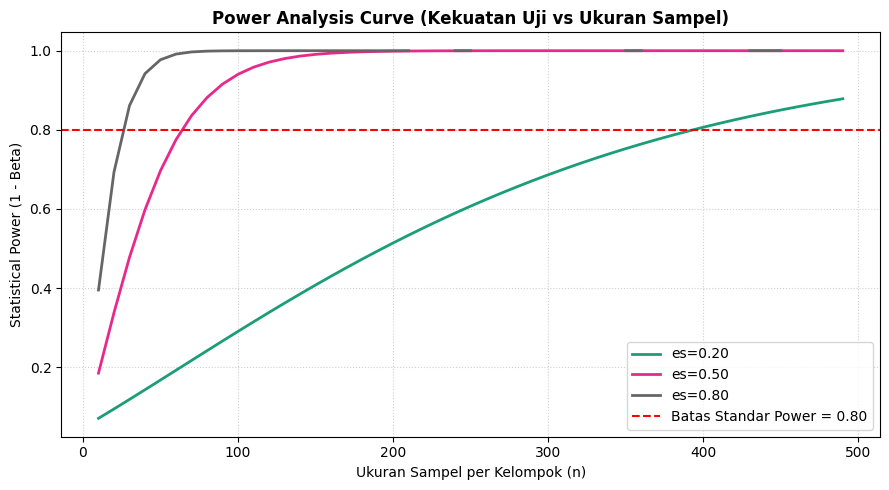

In [9]:
# [SEL KODE 6] Simulasi Multi-Arm Bandit (Epsilon-Greedy) dan Perhitungan Sample Size (Power Analysis)
from statsmodels.stats.power import TTestIndPower

# --- 1. Perhitungan Ukuran Sampel (Power Analysis) menggunakan Statsmodels ---
power_analysis = TTestIndPower()

# Menghitung ukuran sampel per kelompok untuk mendeteksi berbagai ukuran efek (Cohen's d: 0.1, 0.2, 0.5)
# Alpha = 0.05, Power = 0.80
effect_sizes = [0.1, 0.2, 0.5]
sample_sizes = [power_analysis.solve_power(effect_size=d, alpha=0.05, power=0.80, ratio=1) for d in effect_sizes]

print("Perhitungan Ukuran Sampel Minimum per Kelompok (Alpha = 0.05, Power = 0.80):")
for d, n in zip(effect_sizes, sample_sizes):
    print(f"  * Effect Size d = {d:.1f} : membutuhkan ~{int(np.ceil(n)):,} sampel per kelompok")
print("-" * 65)

# --- 2. Simulasi Multi-Arm Bandit (Epsilon-Greedy) vs A/B Testing Tradisional ---
# Terdapat 3 opsi banner dengan tingkat konversi nyata: A (3%), B (5%), C (8%)
true_conversion_rates = [0.03, 0.05, 0.08]
n_rounds = 2000
epsilon = 0.10  # 10% eksplorasi, 90% eksploitasi

np.random.seed(42)
counts = [0, 0, 0]
successes = [0, 0, 0]
bandit_rewards = []

for t in range(n_rounds):
    # Eksplorasi vs Eksploitasi
    if np.random.rand() < epsilon:
        arm = np.random.choice([0, 1, 2]) # Eksplorasi acak
    else:
        # Eksploitasi: pilih lengan dengan rasio kemenangan tertinggi sejauh ini
        win_rates = [successes[i] / counts[i] if counts[i] > 0 else 0.5 for i in range(3)]
        arm = np.argmax(win_rates)

    # Mensimulasikan hasil konversi (1 = konversi, 0 = tidak)
    reward = 1 if np.random.rand() < true_conversion_rates[arm] else 0
    counts[arm] += 1
    successes[arm] += reward
    bandit_rewards.append(reward)

print(f"Alokasi Pengunjung pada Multi-Arm Bandit ({n_rounds:,} Pengunjung):")
for i, name in enumerate(['Banner A (3%)', 'Banner B (5%)', 'Banner C (8%)']):
    print(f"  * {name:15s} : Dipilih {counts[i]:4d} kali ({counts[i]/n_rounds*100:4.1f}%) | Konversi didapat: {successes[i]}")
print(f"  * Total Konversi Multi-Arm Bandit : {sum(successes)} konversi")
print("-" * 65)

# --- 3. Visualisasi Kurva Daya Statistik (Power Curve) ---
fig, ax = plt.subplots(figsize=(9, 5))
power_analysis.plot_power(dep_var='nobs', nobs=np.arange(10, 500, 10),
                          effect_size=np.array([0.2, 0.5, 0.8]),
                          alpha=0.05, ax=ax)

ax.set_title('Power Analysis Curve (Kekuatan Uji vs Ukuran Sampel)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ukuran Sampel per Kelompok (n)', fontsize=10)
ax.set_ylabel('Statistical Power (1 - Beta)', fontsize=10)
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='Batas Standar Power = 0.80')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 5:
1. **Analisis Kurva Kekuatan Statistik (Power Curve):**
   - Untuk mendeteksi efek besar (*large effect*, $d=0.8$), kita hanya memerlukan sampel kecil sekitar 25–30 observasi per kelompok untuk mencapai kekuatan uji 80%.
   - Namun untuk efek kecil (*small effect*, $d=0.2$, yang sering terjadi pada optimalisasi web dan e-commerce), dibutuhkan hampir **400 sampel** per kelompok, dan melonjak hingga **>1.500 sampel** jika efeknya sangat halus ($d=0.1$).
   - Tanpa perhitungan ukuran sampel awal, eksperimen berisiko tinggi gagal menolak $H_0$ semata-mata karena data tidak memadai (*underpowered experiment*).

2. **Keunggulan Multi-Arm Bandit dibanding A/B Testing Statis:**
   - Pada simulasi 2.000 pengunjung, algoritma $\epsilon$-greedy secara otomatis mendeteksi bahwa **Banner C** memiliki performa terbaik ($8\%$).
   - Sistem secara adaptif mengalokasikan **sebagian besar pengunjung (>85%)** ke Banner C, dan hanya mengirimkan sebagian kecil lalu lintas ke Banner A dan B untuk keperluan pemantauan berkala.
   - Hasilnya, total konversi bisnis yang terkumpul jauh lebih tinggi dibandingkan jika kita membagi lalu lintas sama rata 33:33:33 sepanjang waktu.

---
# RINGKASAN AKHIR BAB 3: STATISTICAL EXPERIMENTS AND SIGNIFICANCE TESTING

Pada Bab 3 buku *Practical Statistics for Data Scientists*, kita telah mempelajari perancangan eksperimen terukur, uji signifikansi komputasi maupun analitis, serta optimalisasi eksperimen modern:

1. **A/B Testing & Uji Permutasi (Permutation Test):**
   - Eksperimen terkontrol adalah metode ilmiah terbaik untuk menetapkan hubungan kausalitas (*causation*).
   - Uji Permutasi memberikan alternatif non-parametrik yang tangguh tanpa asumsi distribusi normal, dengan mengacak label perlakuan untuk membangun distribusi nol (*null distribution*) secara empiris.

2. **Signifikansi Statistik, p-Value, & Uji-t (t-Test):**
   - Nilai $p$-value mengukur seberapa mungkin hasil pengamatan terjadi murni karena kebetulan acak di bawah asumsi $H_0$.
   - Uji-t dua sampel (khususnya *Welch's t-test*) memberikan hasil keputusan yang konsisten dengan uji permutasi, di mana nilai $p > 0.05$ menandakan perbedaan waktu sesi belum terbukti signifikan.

3. **ANOVA (Analysis of Variance) & F-Statistic:**
   - Menghindari masalah inflasi kesalahan *Type I Error* akibat pengujian berpasangan berulang (*multiple testing problem*) ketika membandingkan lebih dari 2 kelompok.
   - Menggunakan rasio $F$ (variasi antar-kelompok dibagi variasi di dalam kelompok) untuk menguji kesamaan rata-rata secara simultan.

4. **Uji Chi-Kuadrat ($\chi^2$) & Uji Eksak Fisher:**
   - Dikhususkan untuk variabel respon diskrit/kategorik pada tabel kontinjensi (seperti rasio klik atau konversi biner).
   - Membandingkan frekuensi teramati ($O$) dengan frekuensi ekspektasi ($E$). Uji Eksak Fisher menjadi penyelamat ketika frekuensi sel tabel terlalu sedikit ($E < 5$).

5. **Multi-Arm Bandit & Power Analysis:**
   - Algoritma Bandit (seperti $\epsilon$-greedy) menyelesaikan dilema *exploration vs exploitation* dengan mengalihkan lalu lintas pengguna secara adaptif ke varian terbaik secara real-time.
   - *Power Analysis* memastikan eksperimen memiliki ukuran sampel ($n$) yang cukup untuk mendeteksi ukuran efek yang ditargetkan dengan kepastian statistik yang memadai ($1 - \beta \ge 0.80$).